<a href="https://colab.research.google.com/github/arshaknihal/ComputerVision_Parallel_project/blob/main/Computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [14]:
import os
import cv2
import numpy as np

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout

# Read the data

In [4]:
filepath = '/content/drive/MyDrive/ICT Ai Ml/Colab Notebooks/Data/images'


# Load Images

In [6]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

IMG_SIZE = (128, 128) # Define IMG_SIZE

X=[]
y=[]

for file in os.listdir(filepath): # Use filepath instead of DATASET_PATH
    if file.lower().endswith(('.jpg','.jpeg','.png')):
        label='_'.join(file.split('_')[:-1])
        img=load_img(os.path.join(filepath,file),target_size=IMG_SIZE)
        img=img_to_array(img)
        X.append(img)
        y.append(label)

X=np.array(X,dtype='float32')
y=np.array(y)

print(X.shape)
print('Classes:',len(np.unique(y)))

(5271, 128, 128, 3)
Classes: 27


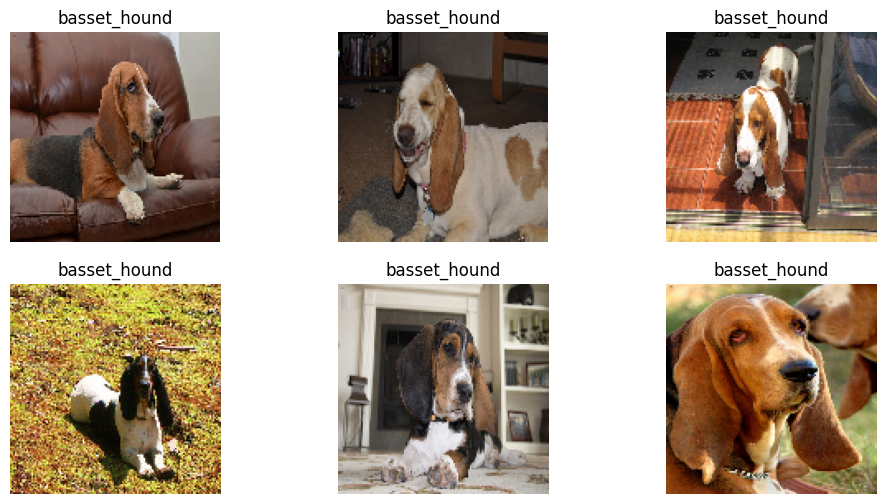

In [7]:
plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X[i].astype('uint8'))
    plt.title(y[i])
    plt.axis('off')
plt.show()


In [8]:
encoder=LabelEncoder()
y_encoded=encoder.fit_transform(y)
y_cat=to_categorical(y_encoded)
class_names=encoder.classes_
print(class_names[:5])


['Abyssinian' 'Bengal' 'Birman' 'Bombay' 'British_Shorthair']


In [9]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y_cat,test_size=0.2,random_state=42,stratify=y_encoded)


In [10]:
X_train=X_train/255.0
X_test=X_test/255.0


In [16]:
model=Sequential([
Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
BatchNormalization(),
MaxPooling2D(),

Conv2D(64,(3,3),activation='relu'),
BatchNormalization(),
MaxPooling2D(),

Conv2D(128,(3,3),activation='relu'),
BatchNormalization(),
MaxPooling2D(),

Conv2D(256,(3,3),activation='relu'),
MaxPooling2D(),

Flatten(),
Dense(512,activation='relu'),
Dropout(0.5),
Dense(len(class_names),activation='softmax')
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 27)             │        13,851 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,122,267 (19.54 MB)

 Trainable params: 5,121,819 (19.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])


In [ ]:
history=model.fit(
X_train,
y_train,
epochs=20,
batch_size=32,
validation_split=0.2)


Epoch 1/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 214s 2s/step - accuracy: 0.0753 - loss: 3.5970 - val_accuracy: 0.0474 - val_loss: 3.8332
Epoch 2/20
 86/106 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.1487 - loss: 3.0104

In [ ]:
loss,acc=model.evaluate(X_test,y_test)
print("Test Accuracy:",acc)


In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.title('Loss')
plt.show()


In [ ]:
pred=np.argmax(model.predict(X_test),axis=1)
true=np.argmax(y_test,axis=1)

print(classification_report(true,pred,target_names=class_names))


In [ ]:
cm=confusion_matrix(true,pred)
print(cm)


In [ ]:
image_path='/content/drive/MyDrive/ICT Ai Ml/Colab Notebooks/Data/Abyssinian_1.jpg'

img=load_img(image_path,target_size=IMG_SIZE)
arr=img_to_array(img)/255.0
pred=model.predict(np.expand_dims(arr,0))
print("Prediction:",class_names[np.argmax(pred)])

plt.imshow(img)
plt.axis('off')
plt.show()
